In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Zomato_Restaurant_Analysis\zomato.csv")

In [3]:
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [4]:
df=df.drop(['url','address','phone','reviews_list','menu_item'],axis=1)

In [9]:
print("Remaining columns:", df.columns)

Remaining columns: Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')


In [10]:
print("Shape after dropping:", df.shape)

Shape after dropping: (51717, 12)


In [11]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


In [12]:
# Some restaurants have "NEW" written instead of a rating — we remove those rows because NEW is not a number
df = df[df['rate'] != 'NEW']


In [15]:
# Some restaurants have "-" instead of rating — we remove those too 
df = df[df['rate'] != '-']

In [14]:
# Remove all rows where rate is empty/blank
df = df.dropna(subset=['rate'])

In [16]:
# Rate column has values like "4.1/5" — we:Convert to number → 4.1 
df['rate'] = df['rate'].str.replace('/5', '').str.strip().astype(float)

In [17]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '').astype(float)

In [29]:
df['dish_liked'] = df['dish_liked'].fillna('Not Available')
df['rest_type'] = df['rest_type'].fillna('Not Specified')
df['cuisines'] = df['cuisines'].fillna('Not Specified')

In [31]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].median())

In [32]:
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: int64


In [18]:
df

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...
51709,The Farm House Bar n Grill,No,No,3.7,34,Whitefield,"Casual Dining, Bar",NaN,"North Indian, Continental",800.0,Pubs and bars,Whitefield
51711,Bhagini,No,No,2.5,81,Whitefield,"Casual Dining, Bar","Biryani, Andhra Meal","Andhra, South Indian, Chinese, North Indian",800.0,Pubs and bars,Whitefield
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,NaN,Continental,1500.0,Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2500.0,Pubs and bars,Whitefield


# visualizations

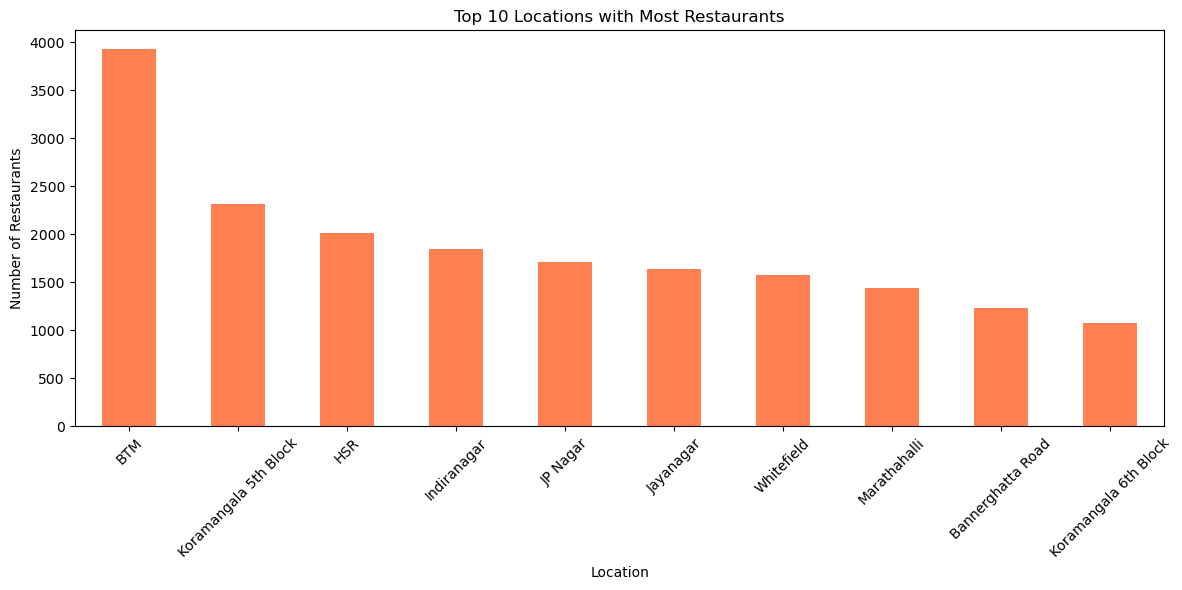

In [19]:
# 1. Top 10 locations by number of restaurants
plt.figure(figsize=(12,6))
df['location'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Locations with Most Restaurants')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

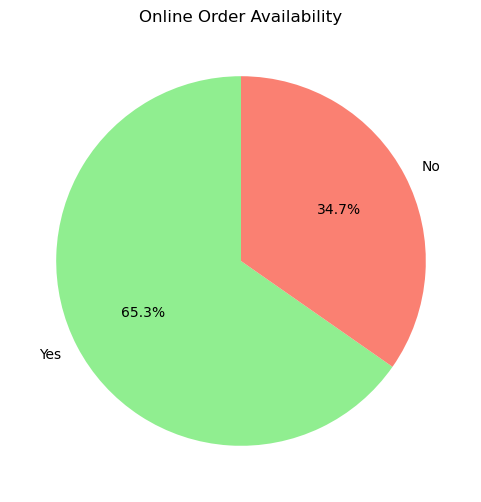

In [20]:
# 2. Online Order distribution
plt.figure(figsize=(6,6))
df['online_order'].value_counts().plot(kind='pie', 
    autopct='%1.1f%%', 
    colors=['lightgreen','salmon'],
    startangle=90)
plt.title('Online Order Availability')
plt.ylabel('')
plt.show()

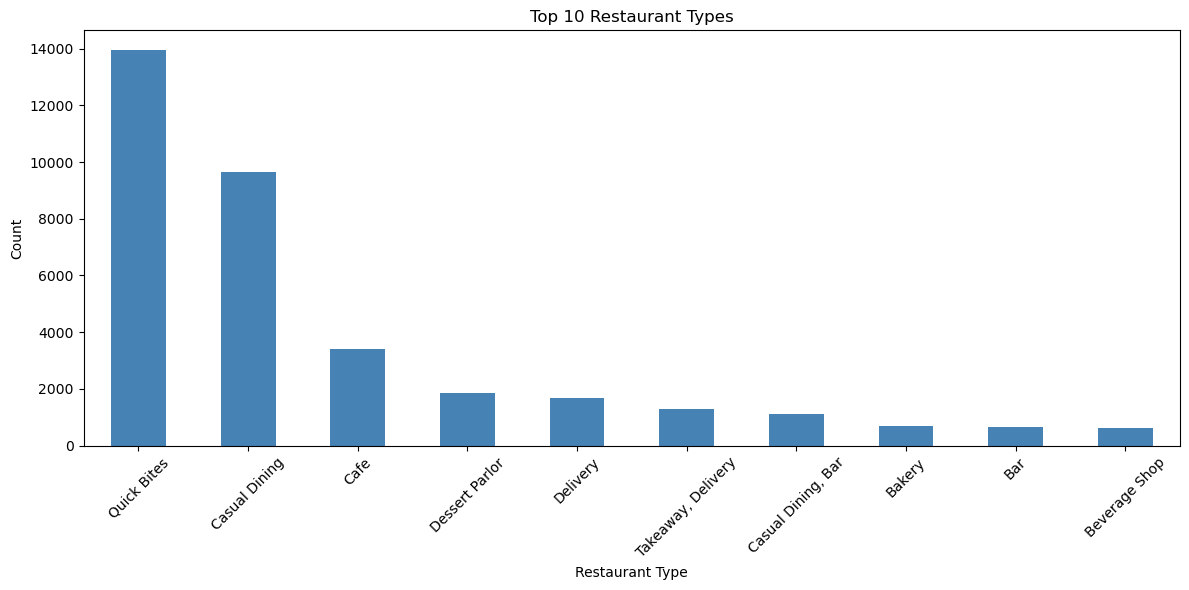

In [21]:
# 3. Top 10 restaurant types
plt.figure(figsize=(12,6))
df['rest_type'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Restaurant Types')
plt.xlabel('Restaurant Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

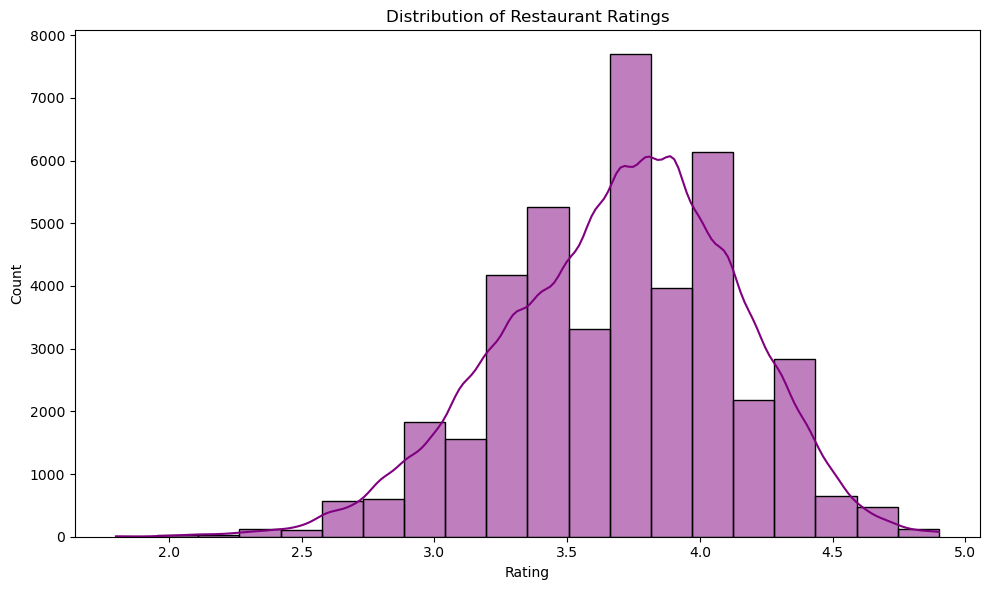

In [22]:
# 4. Ratings distribution
plt.figure(figsize=(10,6))
sns.histplot(df['rate'], bins=20, color='purple', kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
Key Finding:Most restaurants in Bengaluru are rated between 3.5 to 4.0
This means:
Bengaluru restaurants are generally good quality
Very few restaurants are extremely bad (below 2.5)
Very few restaurants are extremely excellent (above 4.5)

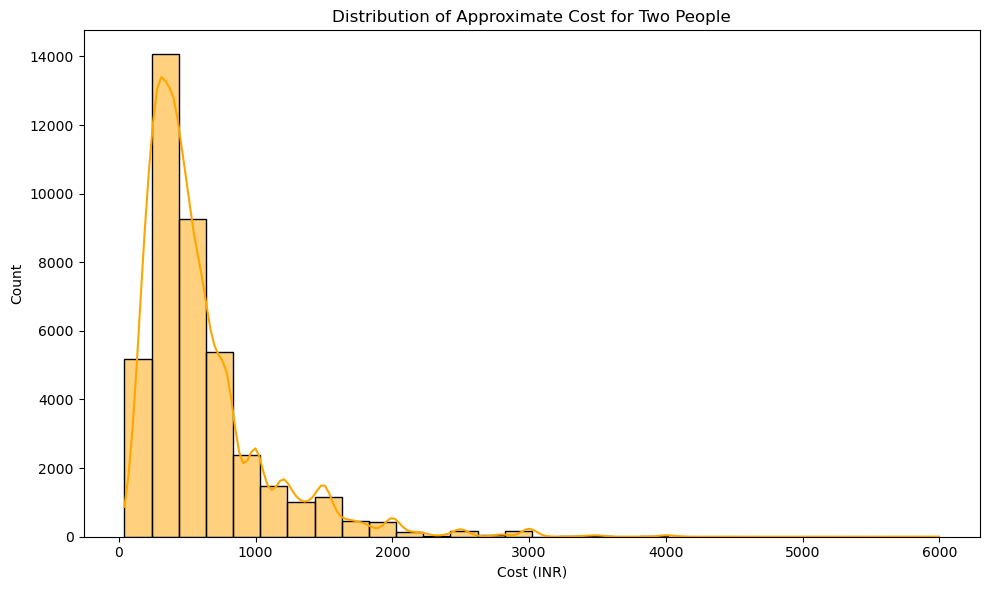

In [23]:
# 5. Average cost distribution
plt.figure(figsize=(10,6))
sns.histplot(df['approx_cost(for two people)'], 
             bins=30, color='orange', kde=True)
plt.title('Distribution of Approximate Cost for Two People')
plt.xlabel('Cost (INR)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
Key Finding:
Most Bengaluru restaurants are budget friendly (₹200-₹500 for two people)
This means Bengaluru has mostly affordable eating options!

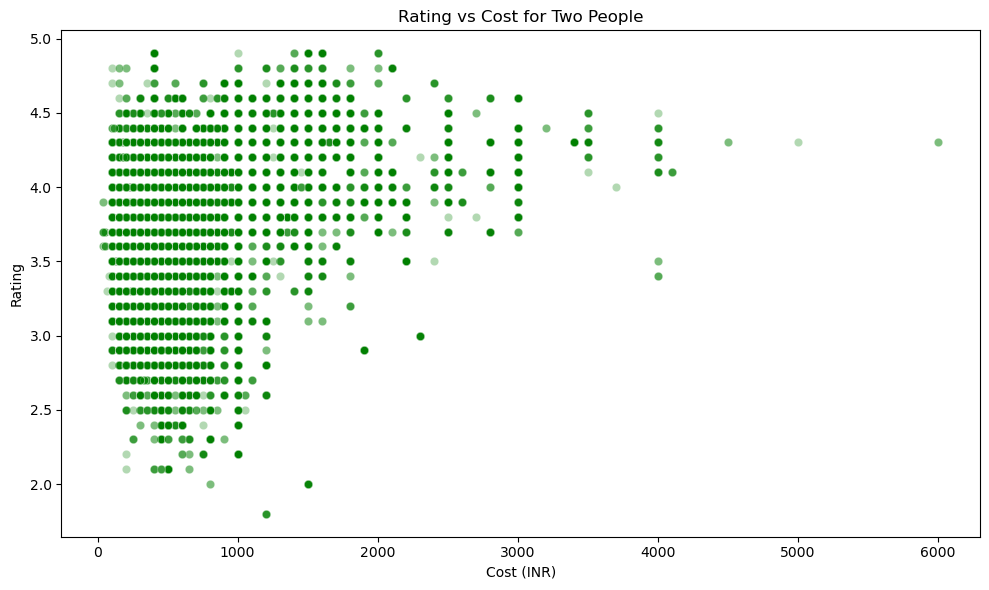

In [24]:
# 6. Rating vs Cost relationship
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, 
                x='approx_cost(for two people)', 
                y='rate',
                alpha=0.3,
                color='green')
plt.title('Rating vs Cost for Two People')
plt.xlabel('Cost (INR)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

In [ ]:
Key Finding 🎯
Price does NOT always mean better rating!
Many affordable restaurants (₹300-₹500) have ratings of 4.0 and above!


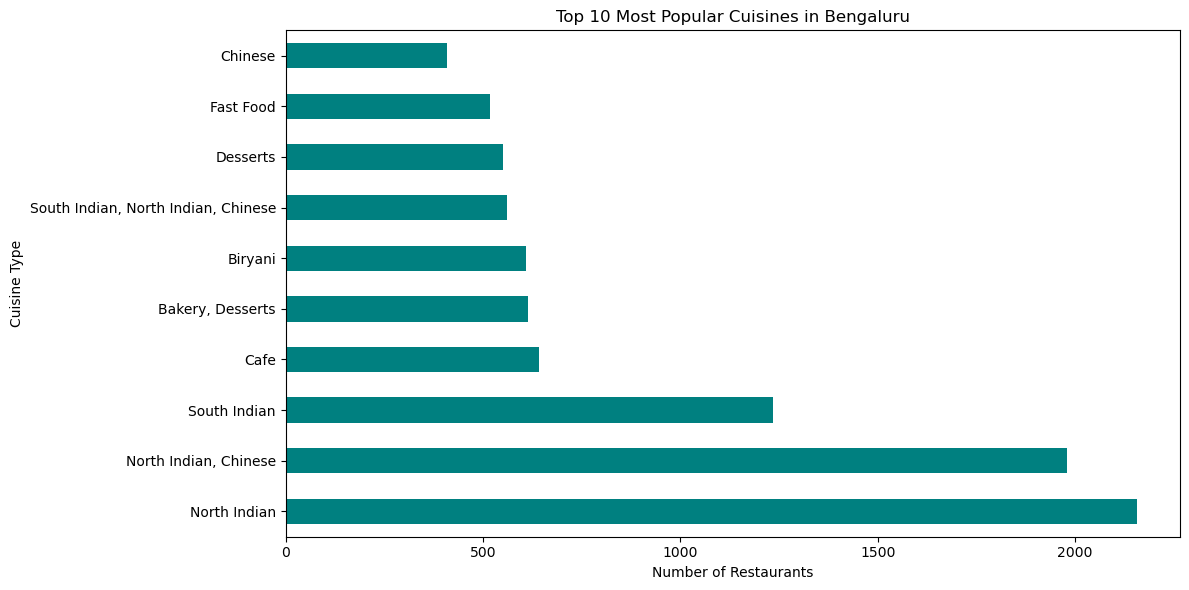

In [25]:
# 7. Top 10 most popular cuisines
plt.figure(figsize=(12,6))
df['cuisines'].value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Popular Cuisines in Bengaluru')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.show()

In [33]:
# Save cleaned data for SQL
df.to_csv('zomato_cleaned.csv', index=False)
print("Cleaned data saved successfully!")
print("Shape:", df.shape)

Cleaned data saved successfully!
Shape: (41665, 12)


In [34]:
from sqlalchemy import create_engine
import urllib.parse

username = "root"
password = urllib.parse.quote_plus("Teja_yadav@8008")  # your password
host = "127.0.0.1"
port = "3306"
database = "zomato_analysis"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Upload data to MySQL
df.to_sql('zomato_restaurants', engine, if_exists='replace', index=False)
print("Data uploaded successfully!")

Data uploaded successfully!
